<a href="https://colab.research.google.com/github/moscopito/mosco/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Checking files:
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject1.csv, Exists: True
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject2.csv, Exists: True
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject3.csv, Exists: True
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject4.csv, Exists: True
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject5.csv, Exists: True
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject6.csv, Exists: True
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject7.csv, Exists: True
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject8.csv, Exists: True
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject9.csv, Exists: True
Looking for: /content/drive/MyDrive/Colab Notebooks/data/mHealth_subject10.csv, Exists: True
Shape after cleaning: (1215735, 23)
S

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.6948 - loss: 1.2735 - val_accuracy: 0.6868 - val_loss: 1.9171
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.7376 - loss: 0.8714 - val_accuracy: 0.6868 - val_loss: 1.5198
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.7541 - loss: 0.8138 - val_accuracy: 0.6880 - val_loss: 1.2464
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7901 - loss: 0.6945 - val_accuracy: 0.6843 - val_loss: 1.3583
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.7832 - loss: 0.6635 - val_accuracy: 0.7053 - val_loss: 1.1062
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.7901 - loss: 0.6321 - val_accuracy: 0.7152 - val_loss: 1.0393
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7706 - loss: 0.6419 - val_accuracy: 0.7300 - val_loss: 1.2369
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8066 - loss: 0.5664 - val_accuracy: 0.7226 - 

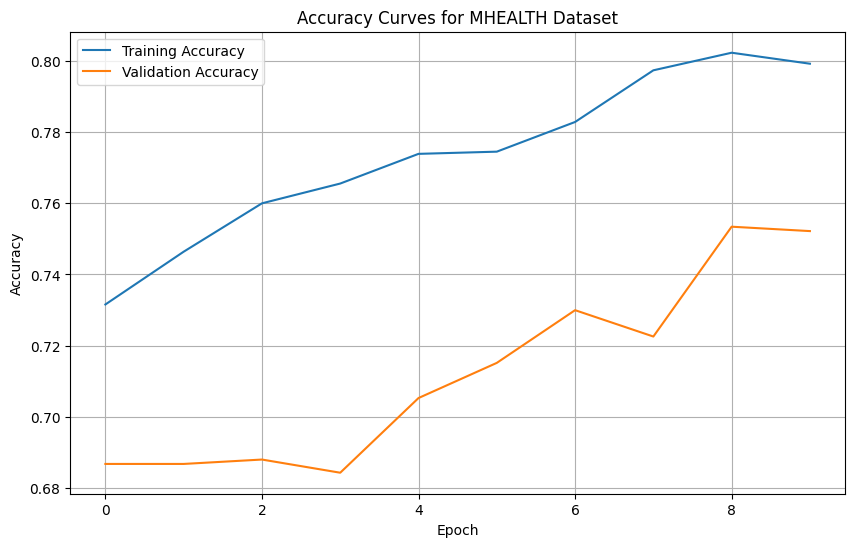

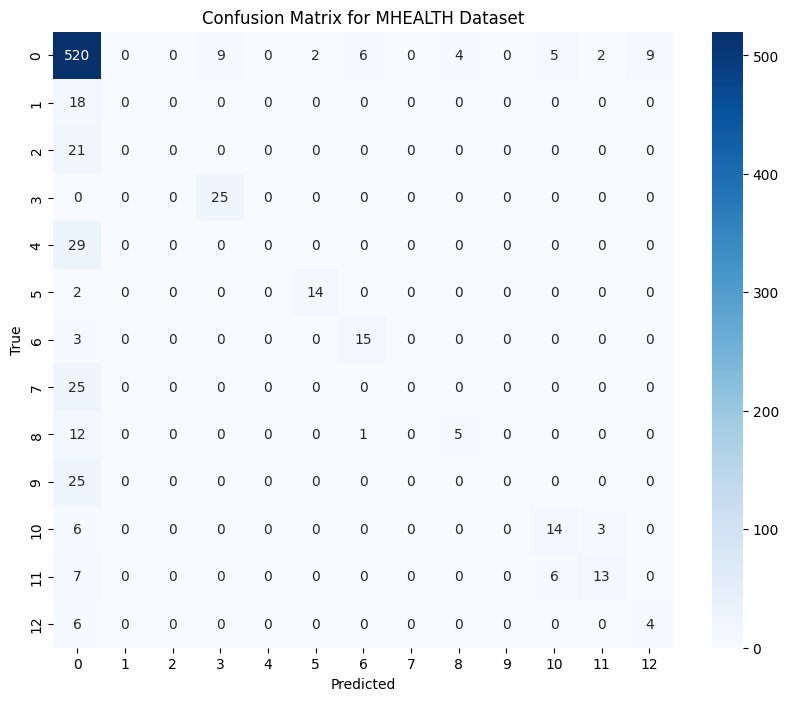

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from google.colab import drive
import os

# Step 1: Data Loading and Preprocessing
def load_mhealth_data(file_paths):
    data_list = []
    labels_list = []
    for file_path in file_paths:
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, sep=',', skiprows=1)  # Skip header row
            data = df.iloc[:, :-1].values  # 23 sensor columns
            labels = df.iloc[:, -1].values  # Label column
            data_list.append(data)
            labels_list.append(labels)
        else:
            print(f"File not found: {file_path}")
    data = np.concatenate(data_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    # Clean labels
    mask = ~np.isnan(labels)  # Remove nan
    data = data[mask]
    labels = labels[mask]
    valid_labels = np.logical_and(labels >= 0, labels < 14)  # MHEALTH has 13 classes (0-12)
    if not np.all(valid_labels):
        print(f"Invalid labels found: {labels[~valid_labels]}")
        labels[~valid_labels] = 0  # Replace invalid with 0
    # Normalize data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)
    print(f"Shape after cleaning: {data.shape}")
    return data, labels

# Step 2: Windowing and GAF Transformation
def compute_gaf(data):
    data_normalized = np.clip(data, -1 + 1e-10, 1 - 1e-10, out=data)  # In-place clipping
    theta = np.arccos(data_normalized)
    if np.any(np.isnan(theta)):
        print("NaN detected in theta, replacing with 0")
        theta = np.nan_to_num(theta, nan=0.0)
    N = len(data_normalized)
    gasf = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            gasf[i, j] = np.cos(theta[i] + theta[j])
    return gasf

def time_series_to_images(data, window_size=300, selected_channels=[0, 1, 2]):
    images = []
    max_windows = len(data) - window_size + 1
    for i in range(0, max_windows, window_size):  # Non-overlapping windows
        window = data[i:i + window_size, selected_channels]
        if window.shape[0] == window_size:
            gaf_images = [compute_gaf(window[:, j]) for j in range(window.shape[1])]
            gaf_images = [np.resize(gaf, (10, 10)) for gaf in gaf_images]  # Fixed size for CNN
            gaf_image = np.stack(gaf_images, axis=-1) if len(gaf_images) == 3 else np.stack([gaf_images[0]]*3, axis=-1)
            images.append(gaf_image)
    return np.array(images)

# Step 3: Model Architecture
def build_densenet_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(64, (3, 3), strides=1, padding='same', input_shape=input_shape),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(32, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(32, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(32, (1, 1), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Step 4: Training and Evaluation
def main():
    drive.mount("/content/drive", force_remount=True)
    base_path = '/content/drive/MyDrive/Colab Notebooks/data/'
    file_paths = [f'{base_path}mHealth_subject{i}.csv' for i in range(1, 11)]
    print("Checking files:")
    for path in file_paths:
        print(f"Looking for: {path}, Exists: {os.path.exists(path)}")
    data, labels = load_mhealth_data(file_paths)
    print(f"Shape of raw data: {data.shape}")
    window_size = 300  # Per paper (Table 4)
    images = time_series_to_images(data, window_size, selected_channels=[0, 1, 2])
    print(f"Shape of images: {images.shape}")
    image_labels = labels[window_size-1::window_size]
    min_len = min(len(images), len(image_labels))
    images = images[:min_len]
    image_labels = image_labels[:min_len]
    print(f"Shape of final images: {images.shape}, Shape of final labels: {image_labels.shape}")
    X_train, X_test, y_train, y_test = train_test_split(images, image_labels, test_size=0.2, random_state=42)
    num_classes = len(np.unique(labels))
    model = build_densenet_model(input_shape=(10, 10, 3), num_classes=num_classes)
    history = model.fit(X_train, y_train, epochs=10, batch_size=35, validation_data=(X_test, y_test), verbose=1)
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, y_pred_classes)
    f1 = f1_score(y_test, y_pred_classes, average='weighted')
    print(f"Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}")
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e')
    plt.title('Accuracy Curves for MHEALTH Dataset')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig('/content/accuracy_curves.png')
    plt.show()
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix for MHEALTH Dataset')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig('/content/confusion_matrix.png')
    plt.show()

if __name__ == "__main__":
    main()
